# Energy-dependent potentials

This notebook demonstrates the `energy_dependent=True` workflow:

1. Define a potential whose depth varies with energy.
2. Compile a solver with `energy_dependent=True`.
3. Compute a batched `Spectrum` via `solver.spectrum`'s internal dispatch.
4. Use the aligned-grid helpers (`phases_grid`) to get phase shifts.
5. Build a Padé interpolant and compare it against the full reference grid.

The toy system is an s-wave Gaussian optical potential
$V(r; E) = -V_0(E)\,e^{-r^2/a^2}$ with a linear energy dependence
$V_0(E) = V_1 + V_2 E$.

In [1]:
from __future__ import annotations

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import lax as lm
import lax.constants as C

In [2]:
# --- System parameters -----------------------------------------------
HBAR2_2MU = C.hbar2_over_2mu(1.008665, 1.008665)  # n-n  MeV·fm²
A = 2.0  # Gaussian range [fm]
V1 = 60.0  # depth at E=0  [MeV]
V2 = -0.5  # linear E-dependence  [MeV/MeV]


def gaussian_depth(energy: float | jnp.ndarray) -> float | jnp.ndarray:
    return V1 + V2 * energy


def gaussian_potential(radii: jnp.ndarray, energy: float) -> jnp.ndarray:
    return -gaussian_depth(energy) * jnp.exp(-((radii / A) ** 2))

## Compile the solver

Pass `energy_dependent=True` and an explicit `energies` grid.
The solver bundles boundary values for every grid point.

In [3]:
N_COARSE = 16  # coarse grid for the energy-dependent solve
N_FINE = 200  # dense reference grid (energy-independent solve at each E)

energies_coarse = jnp.linspace(1.0, 30.0, N_COARSE)
energies_fine = jnp.linspace(1.0, 30.0, N_FINE)

solver = lm.compile(
    mesh=lm.MeshSpec("legendre", "x", n=20, scale=10.0),
    channels=(lm.ChannelSpec(l=0, threshold=0.0, mass_factor=HBAR2_2MU),),
    solvers=("spectrum", "phases"),
    energies=energies_coarse,
    energy_dependent=True,
)
print(solver)

Solver(legendre/x n=20 scale=10.0fm, method=eigh, 16 energies)
  observables: spectrum rmatrix smatrix phases eigh rmatrix_grid smatrix_grid phases_grid
  transforms:  integrate


## Build the energy-dependent potential grid

Use `solver.local_potential(fn, energy_dependent=True)` to build an
energy-dependent `Interaction` whose `.block` has shape `(N_E, M, M)`.
Pass the `Interaction` straight to `solver.spectrum` — it dispatches over
the leading energy axis internally for the diagonal `(spec_i, E_i)` pairing.

In [ ]:
# Build the energy-dependent interaction; .block has shape (N_E, M, M)
assert solver.local_potential is not None
interaction = solver.local_potential(gaussian_potential, energy_dependent=True)
V_grid = interaction.block  # (N_E, M, M) = (N_E, N, N) for single channel
print("V_grid shape:", V_grid.shape)

## Compute the batched spectrum and aligned-grid phase shifts

`solver.spectrum` dispatches over the leading energy axis of the
energy-dependent `Interaction` internally, producing one `Spectrum` per
energy.  `solver.phases_grid` then evaluates each spectrum at its own
compile-time energy — the diagonal pairing `(spec_i, E_i)` that is
physically correct for energy-dependent V.

In [ ]:
spectra = solver.spectrum(
    interaction
)  # batched Spectrum (N_E, ...) via internal dispatch
phases_coarse = np.asarray(solver.phases_grid(spectra))[:, 0]  # (N_E,) rad
print("phase shifts at coarse grid (deg):", np.degrees(phases_coarse).round(2))

## Build a Padé interpolant

`solver.interpolate_phases` returns a JIT-compiled callable that accepts
any energy and returns interpolated phase shifts.

In [6]:
interp_phases = solver.interpolate_phases(
    jnp.asarray(phases_coarse[:, None])
)  # (N_E, 1)

# Evaluate interpolant on a fine grid
phases_interp = np.asarray(interp_phases(energies_fine))[:, 0]  # (N_FINE,)

## Reference: energy-independent solves at each fine-grid energy

Compile a fresh solver per fine-grid point would be expensive; instead we
use a single solver on the fine grid with `energy_dependent=False` and
evaluate each potential at its own energy directly.

In [ ]:
solver_ref = lm.compile(
    mesh=lm.MeshSpec("legendre", "x", n=20, scale=10.0),
    channels=(lm.ChannelSpec(l=0, threshold=0.0, mass_factor=HBAR2_2MU),),
    solvers=("spectrum", "phases"),
    energies=energies_fine,
)

assert solver_ref.local_potential is not None
phases_ref = np.empty(N_FINE)
for idx, e in enumerate(np.asarray(energies_fine)):
    e_val = float(e)
    interaction_e = solver_ref.local_potential(lambda r: gaussian_potential(r, e_val))
    spec_e = solver_ref.spectrum(interaction_e)
    phases_ref[idx] = float(solver_ref.phases(spec_e)[idx, 0])

max_err_deg = float(np.max(np.abs(np.degrees(phases_interp - phases_ref))))
print(f"Max Padé interpolation error: {max_err_deg:.4f} degrees")

## Comparison plot

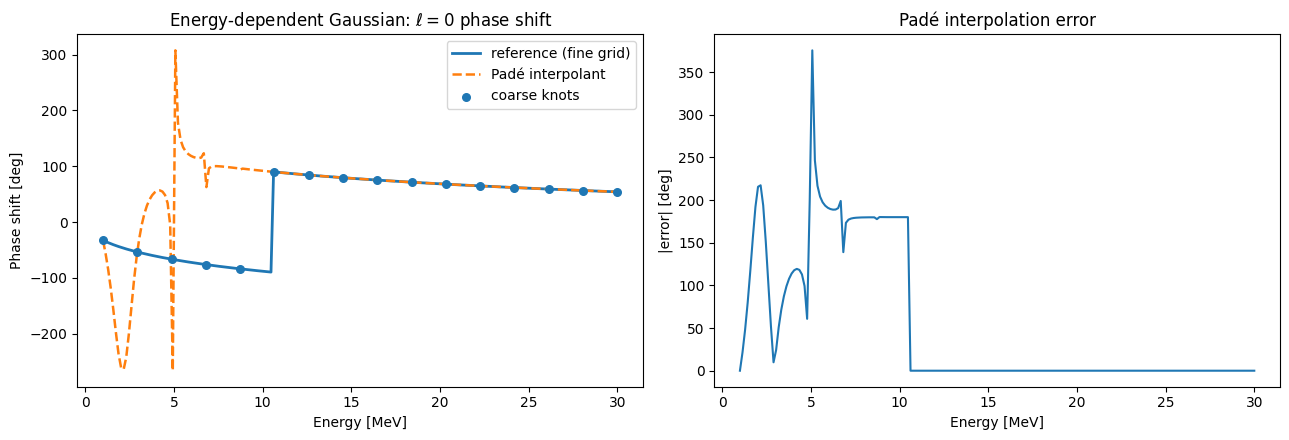

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

E_coarse = np.asarray(energies_coarse)
E_fine = np.asarray(energies_fine)

axes[0].plot(E_fine, np.degrees(phases_ref), label="reference (fine grid)", lw=2)
axes[0].plot(E_fine, np.degrees(phases_interp), "--", label="Padé interpolant", lw=1.8)
axes[0].scatter(
    E_coarse, np.degrees(phases_coarse), zorder=5, label="coarse knots", s=30
)
axes[0].set_xlabel("Energy [MeV]")
axes[0].set_ylabel("Phase shift [deg]")
axes[0].set_title(r"Energy-dependent Gaussian: $\ell=0$ phase shift")
axes[0].legend()

axes[1].plot(E_fine, np.degrees(np.abs(phases_interp - phases_ref)))
axes[1].set_xlabel("Energy [MeV]")
axes[1].set_ylabel("|error| [deg]")
axes[1].set_title("Padé interpolation error")

fig.tight_layout()
plt.show()